In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
import shap
import warnings
warnings.filterwarnings('ignore')

print("Iniciando extração de dados estruturados (FBref e Football-Data)...")

# Extração de dados estatísticos e odds de mercado
url_fbref = "https://web.archive.org/web/20240525141014/https://fbref.com/en/comps/9/2023-2024/schedule/2023-2024-Premier-League-Scores-and-Fixtures"
df_fbref = pd.read_html(url_fbref, match="Wk")[0]
url_stats = "https://www.football-data.co.uk/mmz4281/2324/E0.csv"
colunas_stats = ['HomeTeam', 'AwayTeam', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'B365>2.5', 'B365<2.5']
df_mercado = pd.read_csv(url_stats)[colunas_stats]

# Limpeza e normalização
df_limpo = df_fbref.dropna(subset=['Wk']).copy()
df_limpo = df_limpo[['Home', 'xG', 'Score', 'xG.1', 'Away']].rename(
    columns={'Home': 'Mandante', 'xG': 'xG_Mandante', 'Score': 'Placar', 'xG.1': 'xG_Visitante', 'Away': 'Visitante'}
).dropna()

df_limpo['xG_Mandante'] = pd.to_numeric(df_limpo['xG_Mandante'], errors='coerce')
df_limpo['xG_Visitante'] = pd.to_numeric(df_limpo['xG_Visitante'], errors='coerce')
df_limpo[['Gols_Mandante', 'Gols_Visitante']] = df_limpo['Placar'].str.extract(r'(\d+)[^\d]+(\d+)')
df_limpo = df_limpo.dropna()
df_limpo['Gols_Mandante'] = pd.to_numeric(df_limpo['Gols_Mandante'])
df_limpo['Gols_Visitante'] = pd.to_numeric(df_limpo['Gols_Visitante'])

# Criação da variável alvo (Over 2.5 Gols)
df_limpo['Target_Over25'] = np.where((df_limpo['Gols_Mandante'] + df_limpo['Gols_Visitante']) > 2.5, 1, 0)

# Padronização de nomenclaturas e junção dos DataFrames
dicionario_times = {'Luton Town': 'Luton', 'Manchester City': 'Man City', 'Manchester Utd': 'Man United', 'Newcastle Utd': 'Newcastle', "Nott'ham Forest": "Nott'm Forest", 'Sheffield Utd': 'Sheffield United'}
df_limpo['Mandante_Odds'] = df_limpo['Mandante'].replace(dicionario_times)
df_limpo['Visitante_Odds'] = df_limpo['Visitante'].replace(dicionario_times)
df_base = pd.merge(df_limpo, df_mercado, left_on=['Mandante_Odds', 'Visitante_Odds'], right_on=['HomeTeam', 'AwayTeam'], how='inner')

print("Processamento inicial concluído. Tabela base gerada.")

Iniciando extração de dados estruturados (FBref e Football-Data)...
Processamento inicial concluído. Tabela base gerada.


In [7]:
print("Calculando médias móveis temporais e sistema de pontuação Elo Rating...")

times = pd.concat([df_base['Mandante'], df_base['Visitante']]).unique()

# Estruturas de dados para médias móveis e Elo Rating
historico = {
    'xG': {tm: [] for tm in times}, 'xGA': {tm: [] for tm in times},
    'Chutes': {tm: [] for tm in times}, 'Chutes_Alvo': {tm: [] for tm in times},
    'Escanteios': {tm: [] for tm in times}, 'Faltas': {tm: [] for tm in times}
}

medias = {
    'Casa_xG_Ataque': [], 'Casa_xGA_Defesa': [], 'Fora_xG_Ataque': [], 'Fora_xGA_Defesa': [],
    'Casa_Chutes_5J': [], 'Fora_Chutes_5J': [], 'Casa_ChutesAlvo_5J': [], 'Fora_ChutesAlvo_5J': [],
    'Casa_Escanteios_5J': [], 'Fora_Escanteios_5J': [], 'Casa_Faltas_5J': [], 'Fora_Faltas_5J': []
}

elo_dict = {tm: 1500.0 for tm in times}
K_FACTOR = 20
HOME_ADVANTAGE = 100
elo_mandante_list, elo_visitante_list = [], []

# Iteração temporal rigorosa (prevenção de Data Leakage)
for index, jogo in df_base.iterrows():
    man, vis = jogo['Mandante'], jogo['Visitante']
    
    # 1. Registro de Variáveis Temporais (Médias de 5 Jogos)
    medias['Casa_xG_Ataque'].append(np.mean(historico['xG'][man][-5:]) if len(historico['xG'][man]) > 0 else 0)
    medias['Casa_xGA_Defesa'].append(np.mean(historico['xGA'][man][-5:]) if len(historico['xGA'][man]) > 0 else 0)
    medias['Fora_xG_Ataque'].append(np.mean(historico['xG'][vis][-5:]) if len(historico['xG'][vis]) > 0 else 0)
    medias['Fora_xGA_Defesa'].append(np.mean(historico['xGA'][vis][-5:]) if len(historico['xGA'][vis]) > 0 else 0)
    
    medias['Casa_Chutes_5J'].append(np.mean(historico['Chutes'][man][-5:]) if len(historico['Chutes'][man]) > 0 else 0)
    medias['Fora_Chutes_5J'].append(np.mean(historico['Chutes'][vis][-5:]) if len(historico['Chutes'][vis]) > 0 else 0)
    medias['Casa_ChutesAlvo_5J'].append(np.mean(historico['Chutes_Alvo'][man][-5:]) if len(historico['Chutes_Alvo'][man]) > 0 else 0)
    medias['Fora_ChutesAlvo_5J'].append(np.mean(historico['Chutes_Alvo'][vis][-5:]) if len(historico['Chutes_Alvo'][vis]) > 0 else 0)
    medias['Casa_Escanteios_5J'].append(np.mean(historico['Escanteios'][man][-5:]) if len(historico['Escanteios'][man]) > 0 else 0)
    medias['Fora_Escanteios_5J'].append(np.mean(historico['Escanteios'][vis][-5:]) if len(historico['Escanteios'][vis]) > 0 else 0)
    medias['Casa_Faltas_5J'].append(np.mean(historico['Faltas'][man][-5:]) if len(historico['Faltas'][man]) > 0 else 0)
    medias['Fora_Faltas_5J'].append(np.mean(historico['Faltas'][vis][-5:]) if len(historico['Faltas'][vis]) > 0 else 0)
    
    # 2. Registro do Sistema Elo Rating (Pré-Jogo)
    elo_man_atual, elo_vis_atual = elo_dict[man], elo_dict[vis]
    elo_mandante_list.append(elo_man_atual)
    elo_visitante_list.append(elo_vis_atual)
    
    # 3. Atualização de Dados (Pós-Jogo)
    historico['xG'][man].append(jogo['xG_Mandante']); historico['xGA'][man].append(jogo['xG_Visitante'])
    historico['xG'][vis].append(jogo['xG_Visitante']); historico['xGA'][vis].append(jogo['xG_Mandante'])
    historico['Chutes'][man].append(jogo['HS']); historico['Chutes'][vis].append(jogo['AS'])
    historico['Chutes_Alvo'][man].append(jogo['HST']); historico['Chutes_Alvo'][vis].append(jogo['AST'])
    historico['Escanteios'][man].append(jogo['HC']); historico['Escanteios'][vis].append(jogo['AC'])
    historico['Faltas'][man].append(jogo['HF']); historico['Faltas'][vis].append(jogo['AF'])
    
    # 4. Atualização Matemática do Elo Rating (Pós-Jogo)
    we_man = 1 / (1 + 10 ** ((elo_vis_atual - (elo_man_atual + HOME_ADVANTAGE)) / 400))
    we_vis = 1 / (1 + 10 ** (((elo_man_atual + HOME_ADVANTAGE) - elo_vis_atual) / 400))
    
    w_man = 1 if jogo['Gols_Mandante'] > jogo['Gols_Visitante'] else (0.5 if jogo['Gols_Mandante'] == jogo['Gols_Visitante'] else 0)
    w_vis = 1 - w_man
    
    elo_dict[man] = elo_man_atual + K_FACTOR * (w_man - we_man)
    elo_dict[vis] = elo_vis_atual + K_FACTOR * (w_vis - we_vis)

# Anexando atributos processados ao DataFrame
for chave, valores in medias.items(): df_base[chave] = np.round(valores, 2)
df_base['Elo_Mandante'] = np.round(elo_mandante_list, 2)
df_base['Elo_Visitante'] = np.round(elo_visitante_list, 2)

print("Engenharia de Atributos concluída com sucesso.")

Calculando médias móveis temporais e sistema de pontuação Elo Rating...
Engenharia de Atributos concluída com sucesso.


Iniciando treinamento do modelo XGBoost e simulação de backtest...


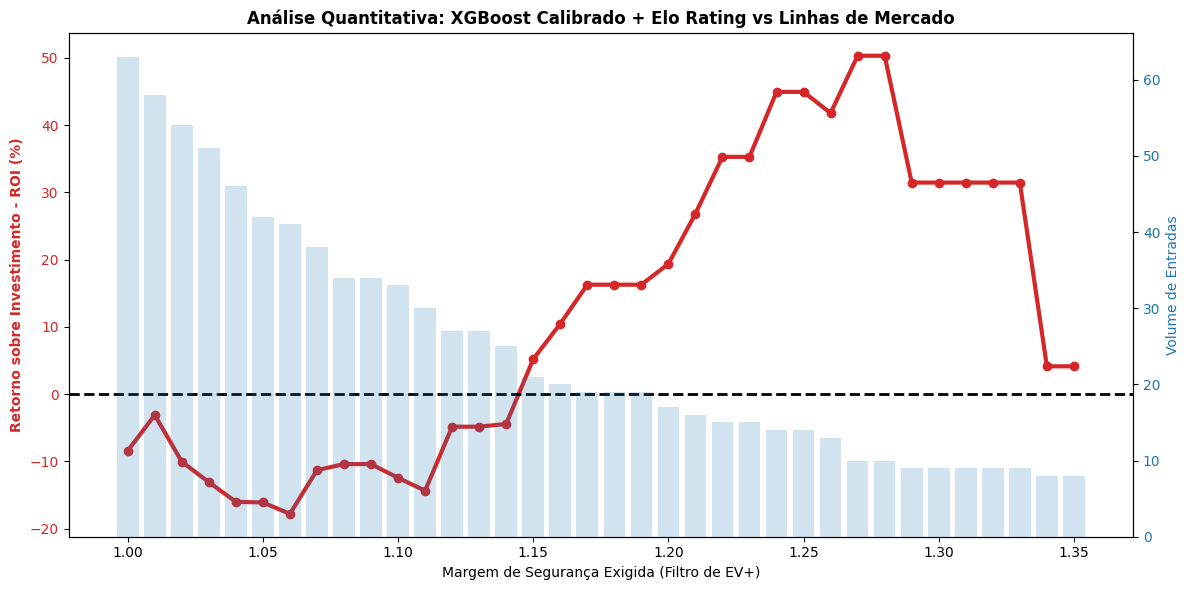

Métricas Finais do Modelo (Teto de Lucro):
Filtro EV+ Otimizado: 1.27
ROI Máximo: 50.30% | Volume de Operações: 10


In [8]:
print("Iniciando treinamento do modelo XGBoost e simulação de backtest...")

atributos_finais = list(medias.keys()) + ['Elo_Mandante', 'Elo_Visitante']
X = df_base[atributos_finais]
y = df_base['Target_Over25']

# Divisão cronológica dos dados (80% treino, 20% teste)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
df_teste = df_base.iloc[split_idx:].copy()

# Treinamento e Calibração de Probabilidades
xgb_base = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42, eval_metric='logloss')
modelo_calibrado = CalibratedClassifierCV(estimator=xgb_base, method='sigmoid', cv=5).fit(X_train, y_train)

probs = modelo_calibrado.predict_proba(X_test)
df_teste['Prob_Abaixo'], df_teste['Prob_Acima'] = probs[:, 0], probs[:, 1]

# Backtest focado na detecção de Valor Esperado (EV+)
thresholds = np.arange(1.00, 1.35, 0.01)
resultados_roi, apostas_totais = [], []

for thresh in thresholds:
    banca_temp, apostas_temp = 1000.00, 0
    for _, jogo in df_teste.iterrows():
        ev_acima = jogo['Prob_Acima'] * jogo['B365>2.5']
        ev_abaixo = jogo['Prob_Abaixo'] * jogo['B365<2.5']

        if ev_acima > thresh:
            apostas_temp += 1
            banca_temp += 10.00 * (jogo['B365>2.5'] - 1) if jogo['Target_Over25'] == 1 else -10.00
        elif ev_abaixo > thresh:
            apostas_temp += 1
            banca_temp += 10.00 * (jogo['B365<2.5'] - 1) if jogo['Target_Over25'] == 0 else -10.00
            
    resultados_roi.append(((banca_temp - 1000.00) / (apostas_temp * 10.00)) * 100 if apostas_temp > 0 else 0)
    apostas_totais.append(apostas_temp)

# Visualização Analítica do Backtest
fig, ax1 = plt.subplots(figsize=(12, 6))
cor_roi = 'tab:red'
ax1.set_xlabel('Margem de Segurança Exigida (Filtro de EV+)')
ax1.set_ylabel('Retorno sobre Investimento - ROI (%)', color=cor_roi, fontweight='bold')
ax1.plot(thresholds, resultados_roi, color=cor_roi, linewidth=3, marker='o', label='ROI c/ Elo Rating')
ax1.tick_params(axis='y', labelcolor=cor_roi)
ax1.axhline(0, color='black', linestyle='--', linewidth=2, label='Ponto de Equilíbrio (Zero)')

ax2 = ax1.twinx()  
cor_vol = 'tab:blue'
ax2.set_ylabel('Volume de Entradas', color=cor_vol)  
ax2.bar(thresholds, apostas_totais, color=cor_vol, alpha=0.2, width=0.008)
ax2.tick_params(axis='y', labelcolor=cor_vol)

plt.title('Análise Quantitativa: XGBoost Calibrado + Elo Rating vs Linhas de Mercado', fontweight='bold')
fig.tight_layout(); plt.show()

melhor_roi = max(resultados_roi)
melhor_thresh = thresholds[resultados_roi.index(melhor_roi)]
apostas_finais = apostas_totais[resultados_roi.index(melhor_roi)]

print(f"Métricas Finais do Modelo (Teto de Lucro):")
print(f"Filtro EV+ Otimizado: {melhor_thresh:.2f}")
print(f"ROI Máximo: {melhor_roi:.2f}% | Volume de Operações: {apostas_finais}")

Iniciando análise de interpretabilidade de atributos (SHAP Values)...


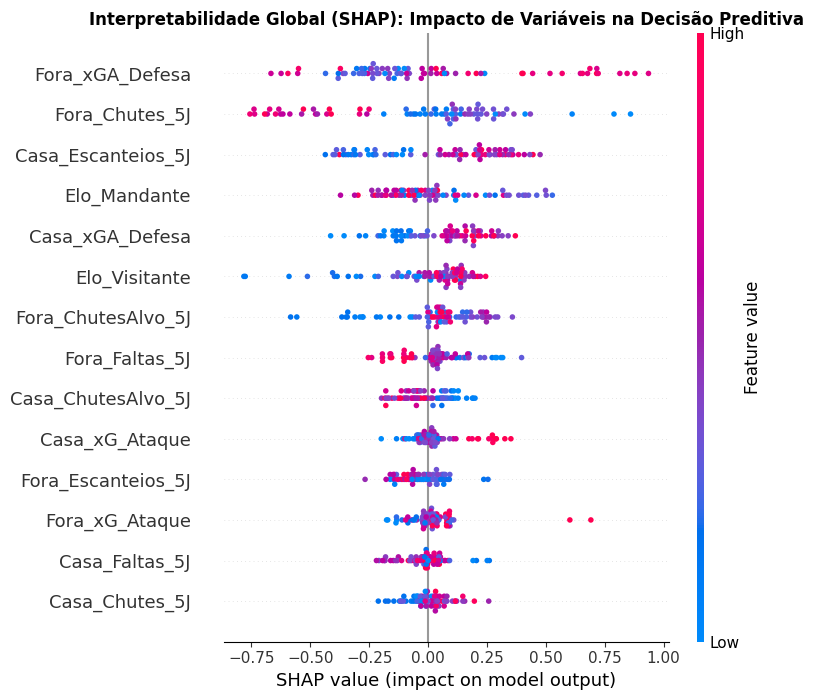

Análise SHAP concluída. Gráfico gerado para avaliação de multicolinearidade e peso de atributos.


In [9]:
print("Iniciando análise de interpretabilidade de atributos (SHAP Values)...")

# Utilizando o modelo base do pipeline calibrado para análise estrutural
modelo_explicativo = modelo_calibrado.calibrated_classifiers_[0].estimator
explainer = shap.TreeExplainer(modelo_explicativo)

shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 8))
plt.title("Interpretabilidade Global (SHAP): Impacto de Variáveis na Decisão Preditiva", fontweight='bold', fontsize=12)
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

print("Análise SHAP concluída. Gráfico gerado para avaliação de multicolinearidade e peso de atributos.")